In [2]:
# Import and Setup
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import time

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
# Load Data
url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'

cols = ['mpg','cylinders','displacement','horsepower','weight','acceleration','model_year','origin','car_name']

df = pd.read_csv(url, names=cols, na_values='?', delim_whitespace=True)
df = df.dropna()
df = df.drop('car_name', axis=1)

X = df.drop('mpg', axis=1).values
y = df['mpg'].values

C:\Users\Ignacio\AppData\Local\Temp\ipykernel_35124\2268888394.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(url, names=cols, na_values='?', delim_whitespace=True)


In [6]:
# Preprocessing
scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32).view(-1,1)

train_loader = DataLoader(TensorDataset(X_train,y_train), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val,y_val), batch_size=32)

In [8]:
# Models
class RgNet1(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(7,1)
    def forward(self,x): return self.fc(x)

class RgNet2(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(7,10), nn.ReLU(),
            nn.Linear(10,20), nn.ReLU(),
            nn.Linear(20,10), nn.ReLU(),
            nn.Linear(10,1)
        )
    def forward(self,x): return self.net(x)

class RgNet3(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(7,10), nn.ReLU(),
            nn.Linear(10,20), nn.ReLU(),
            nn.Linear(20,30), nn.ReLU(),
            nn.Linear(30,20), nn.ReLU(),
            nn.Linear(20,1)
        )
    def forward(self,x): return self.net(x)

In [10]:
# Training Function
def train_rg(model, tr_loader, val_loader, epochs=20, lr=0.01):
    model.to(device)
    crit = nn.MSELoss()
    opt = optim.Adam(model.parameters(), lr=lr)

    tr_losses, val_losses = [], []

    for ep in range(epochs):
        model.train()
        tr_loss = 0

        for x, y in tr_loader:
            x, y = x.to(device), y.to(device)

            opt.zero_grad()
            out = model(x)
            loss = crit(out, y)
            loss.backward()
            opt.step()

            tr_loss += loss.item() * x.size(0)

        tr_loss /= len(tr_loader.dataset)
        tr_losses.append(tr_loss)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                val_loss += crit(model(x), y).item() * x.size(0)

        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)

        print(f"Epoch {ep+1} | Train Loss: {tr_loss:.4f} | Val Loss: {val_loss:.4f}")

    return tr_losses, val_losses

In [12]:
# Train All Models
models = [RgNet1(), RgNet2(), RgNet3()]
val_errs, train_tms = [], []
all_tr_losses, all_val_losses = [], []

for i, mdl in enumerate(models, 1):
    print(f"\nTraining Net {i}")
    start = time.time()

    tr_losses, val_losses = train_rg(mdl, train_loader, val_loader)

    end = time.time()

    train_tms.append(end - start)
    val_errs.append(val_losses[-1])
    all_tr_losses.append(tr_losses)
    all_val_losses.append(val_losses)

best_idx = val_errs.index(min(val_errs))


Training Net 1
Epoch 1 | Train Loss: 616.5681 | Val Loss: 566.7825
Epoch 2 | Train Loss: 604.9632 | Val Loss: 556.4054
Epoch 3 | Train Loss: 594.2324 | Val Loss: 546.5411
Epoch 4 | Train Loss: 583.4745 | Val Loss: 537.7845
Epoch 5 | Train Loss: 574.8620 | Val Loss: 528.8303
Epoch 6 | Train Loss: 564.9542 | Val Loss: 521.0542
Epoch 7 | Train Loss: 556.5678 | Val Loss: 513.7360
Epoch 8 | Train Loss: 548.6943 | Val Loss: 506.7170
Epoch 9 | Train Loss: 540.8617 | Val Loss: 500.2851
Epoch 10 | Train Loss: 533.8046 | Val Loss: 494.1781
Epoch 11 | Train Loss: 527.4229 | Val Loss: 488.1358
Epoch 12 | Train Loss: 520.4828 | Val Loss: 482.8459
Epoch 13 | Train Loss: 514.4459 | Val Loss: 477.7023
Epoch 14 | Train Loss: 508.7374 | Val Loss: 472.6296
Epoch 15 | Train Loss: 502.7815 | Val Loss: 467.9762
Epoch 16 | Train Loss: 497.4184 | Val Loss: 463.3984
Epoch 17 | Train Loss: 492.2195 | Val Loss: 458.9946
Epoch 18 | Train Loss: 487.0778 | Val Loss: 454.5192
Epoch 19 | Train Loss: 482.0052 | Val L

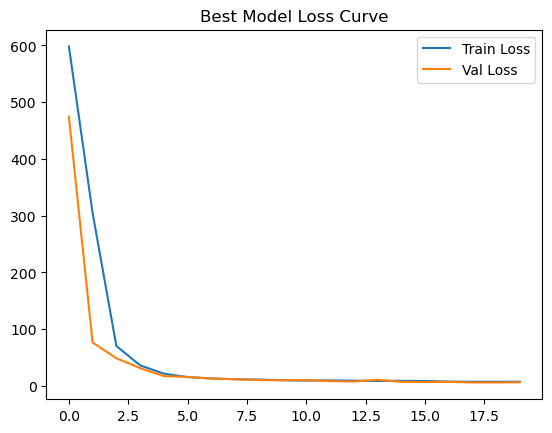

In [14]:
# Plot Best Model Loss
plt.plot(all_tr_losses[best_idx], label="Train Loss")
plt.plot(all_val_losses[best_idx], label="Val Loss")
plt.legend()
plt.title("Best Model Loss Curve")
plt.show()

In [16]:
#Conclusion
print("\nConclusion")

for i in range(3):
    print(f"Net {i+1}:")
    print(f"  Val Loss: {all_val_losses[i][-1]:.4f}")
    print(f"  Train Time: {train_tms[i]:.2f}s")

print(f"\nBest Model: Net {best_idx + 1}")

print("\nWhich of the three models had the least amount of error for validation?")
print(f"- The model with the least validation error is Network {best_idx + 1}.")


Conclusion
Net 1:
  Val Loss: 446.2783
  Train Time: 1.41s
Net 2:
  Val Loss: 7.3167
  Train Time: 0.24s
Net 3:
  Val Loss: 6.4721
  Train Time: 0.27s

Best Model: Net 3

Which of the three models had the least amount of error for validation?
- The model with the least validation error is Network 3.
